#***Project Overview***
---
This project analyzes the Haxby fMRI dataset, in which a subject viewed images from eight categories (faces, houses, cats, bottles, scissors, shoes, chairs, and scrambled images), with ventral temporal cortex responses reduced to 50 principal components. We ask whether the brain represents these categories in distinguishable patterns. First, we explore how mean PC scores differ across categories and between animate and inanimate objects. Next, we train logistic regression and k-nearest-neighbor classifiers to decode whether the subject was viewing a face from brain activity alone, evaluating them with cross-validation. Finally, we use PCA and t-SNE to visualize how the image categories are arranged in the brain's representational space.


#***Housekeeping***



In [ ]:
#Initial importing!
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import accuracy_score, confusion_matrix, ConfusionMatrixDisplay
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

In [ ]:
df = pd.read_csv('Haxby_Reduced.csv')

In [ ]:
df.head()

,PC1,PC2,PC3,PC4,PC5,PC6,PC7,PC8,PC9,PC10,...,PC43,PC44,PC45,PC46,PC47,PC48,PC49,PC50,category,session
0,22.902924,9.937236,4.117603,-4.414197,6.464055,-0.358261,7.426979,-2.960018,-1.802101,7.378876,...,-0.562315,-0.725948,1.489982,0.163816,0.458516,-1.301533,1.112287,-1.537357,scissors,0
1,23.118841,10.623929,6.116805,-1.897333,9.137955,1.991398,7.955241,0.816305,0.881092,8.341912,...,-0.914649,-0.660885,1.910888,-0.279939,0.136691,-0.187726,0.237617,-1.215965,scissors,0
2,23.164461,10.472020,5.781077,-2.949358,6.467790,0.118873,7.262615,1.880418,1.607294,7.707685,...,-0.821352,-0.000830,0.868696,-1.362601,-0.072011,0.342061,-0.746108,-0.617868,scissors,0
3,24.276384,9.842486,5.717005,-5.073019,6.768382,-1.555429,9.634997,2.351414,0.969117,6.799834,...,0.370702,0.213020,1.334632,-0.372242,-0.045337,-0.603027,-0.150477,0.450504,scissors,0
4,24.194920,11.153329,5.148042,-4.504280,6.590526,-1.010427,8.731315,2.035034,1.246951,6.895126,...,-1.020189,0.608991,0.897321,-0.988796,0.843438,-0.126527,-0.386046,0.231578,scissors,0


In [ ]:
df.shape

(864, 52)

In [ ]:
df['category'].unique()

array(['scissors', 'face', 'cat', 'shoe', 'house', 'scrambledpix',
       'bottle', 'chair'], dtype=object)

#***Exploratory Analysis***
---
The Haxby dataset we are analyzing contains fMRI data from a subject viewing an array of images (faces, houses, cats, bottled, scissors, schoes, chairs, and scrambled images). The brain resoonses have been projected into fifty individual principal components (PCs) to capture the dominat axes of variation in the ventral temporal cortex. The central question to our project is: does the brain represent different image categories in distinguishable patterns?

In [ ]:
#Number of trials per category per session
trial_table = df.groupby(['session', 'category']).size().unstack()
print(trial_table)

category  bottle  cat  chair  face  house  scissors  scrambledpix  shoe
session                                                                
0              9    9      9     9      9         9             9     9
1              9    9      9     9      9         9             9     9
2              9    9      9     9      9         9             9     9
3              9    9      9     9      9         9             9     9
4              9    9      9     9      9         9             9     9
5              9    9      9     9      9         9             9     9
6              9    9      9     9      9         9             9     9
7              9    9      9     9      9         9             9     9
8              9    9      9     9      9         9             9     9
9              9    9      9     9      9         9             9     9
10             9    9      9     9      9         9             9     9
11             9    9      9     9      9         9             

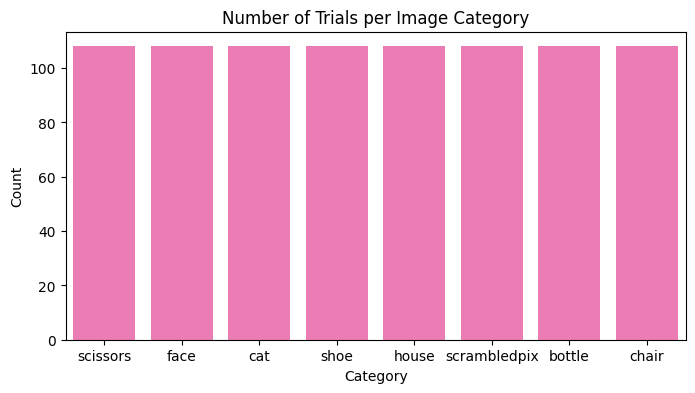

In [ ]:
#Number of trials per image category
plt.figure(figsize = (8,4))
order = df['category'].value_counts().index
sns.countplot(data = df, x = 'category', order = order, color = "hotpink")
plt.xlabel("Category")
plt.ylabel("Count")
plt.title("Number of Trials per Image Category")
plt.show()

In [ ]:
#Calculate the average of each PC for each image category
pc_cols = [f'PC{i}' for i in range(1, 51)]
mean_pc_by_category = df.groupby('category')[pc_cols].mean()

print(mean_pc_by_category)

                   PC1       PC2       PC3       PC4       PC5       PC6  \
category                                                                   
bottle       -0.322317 -0.272482 -0.498198 -0.246988 -0.372392 -0.502033   
cat          -0.454458 -0.095770  1.278729  1.166379 -0.350507 -0.599001   
chair        -0.522013  1.391863  0.383528  2.136354  0.911452 -0.302272   
face          0.151269 -2.378028 -1.406435 -2.143886 -3.450374 -2.572489   
house         1.172834  1.961664  1.106213  2.308260  3.912506  4.315336   
scissors      0.138620 -0.143393 -0.705993 -0.991656  0.710006  0.380989   
scrambledpix -0.175803 -0.733296 -0.955505 -2.032776 -2.160929 -0.717540   
shoe          0.011871  0.269444  0.797666 -0.195683  0.800240 -0.002989   

                   PC7       PC8       PC9      PC10  ...      PC41      PC42  \
category                                              ...                       
bottle       -0.303166  1.632075  0.630217  0.352516  ...  0.336613 -0.354195

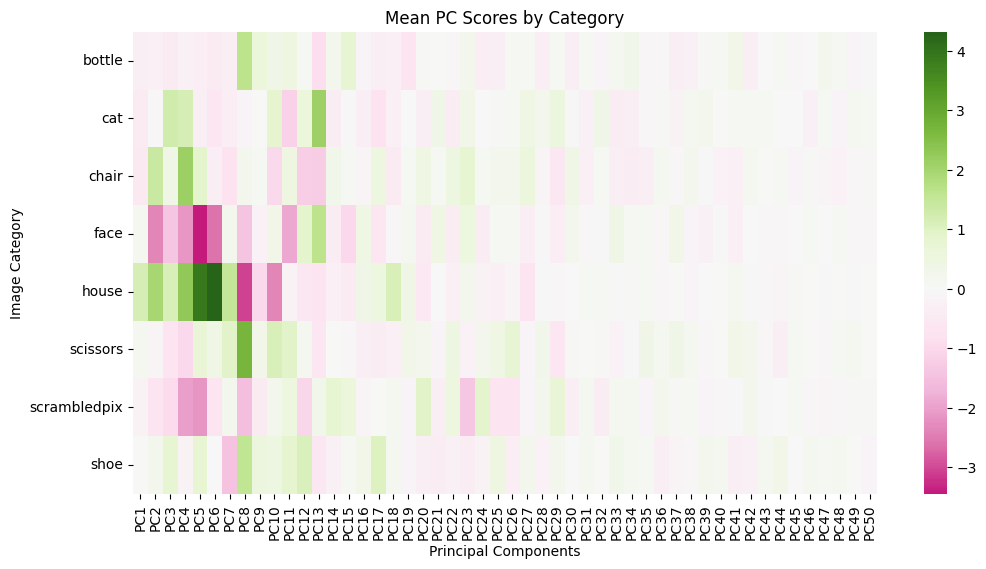

In [ ]:
#Heatmap of average PCs for each image category
plt.figure(figsize=(12, 6))
sns.heatmap(mean_pc_by_category, cmap='PiYG', center=0)
plt.title("Mean PC Scores by Category")
plt.xlabel("Principal Components")
plt.ylabel("Image Category")
plt.show()

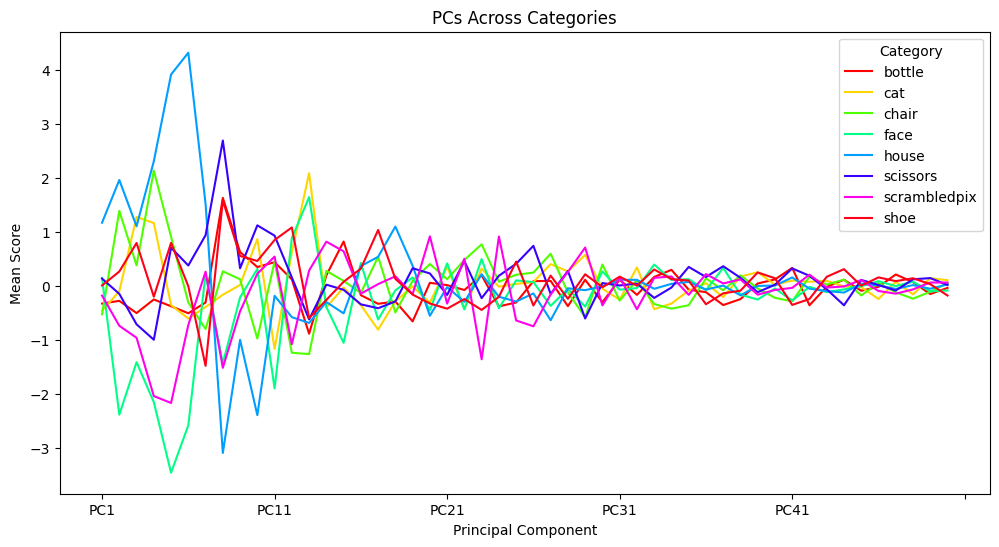

In [ ]:
mean_pc_by_category.T.plot(figsize=(12,6), cmap = "hsv")
plt.title("PCs Across Categories")
plt.xlabel("Principal Component")
plt.ylabel("Mean Score")
plt.legend(title='Category')
plt.show()

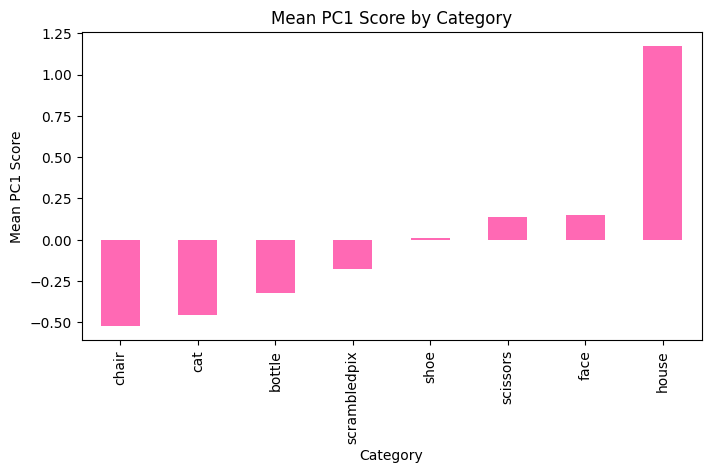

In [ ]:
#Mean PC1 Score Per Category
mean_pc1 = df.groupby('category')['PC1'].mean().sort_values()
plt.figure(figsize = (8,4))
mean_pc1.plot(kind = 'bar', color = 'hotpink',)
plt.title("Mean PC1 Score by Category")
plt.xlabel("Category")
plt.ylabel("Mean PC1 Score")
plt.show()

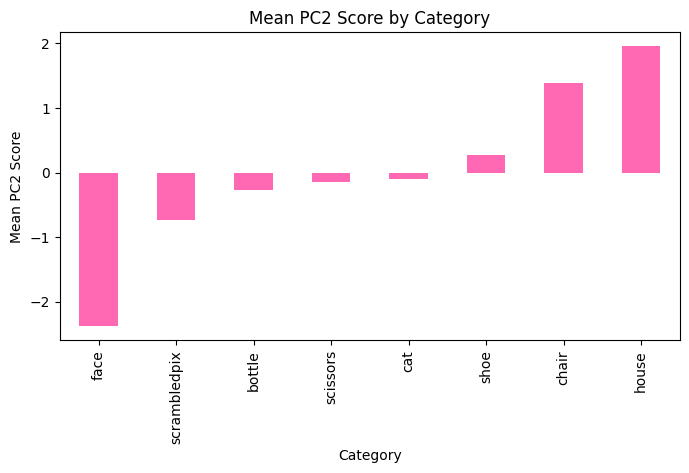

In [ ]:
#Mean PC2 Score Per Category
mean_pc2 = df.groupby('category')['PC2'].mean().sort_values()
plt.figure(figsize = (8,4))
mean_pc2.plot(kind = 'bar', color = 'hotpink',)
plt.title("Mean PC2 Score by Category")
plt.xlabel("Category")
plt.ylabel("Mean PC2 Score")
plt.show()

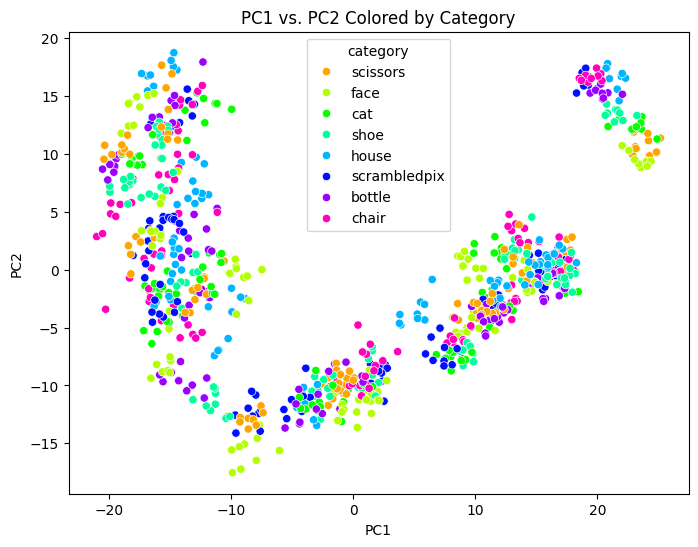

In [ ]:
import seaborn as sns
plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='PC1', y='PC2', hue='category', palette='hsv')
plt.title("PC1 vs. PC2 Colored by Category")
plt.show()

**Animate vs. Inanimate Objects Response**

In [ ]:
animate_categories = ['face', 'cat']
inanimate_categories = ['house', 'scissors', 'shoe', 'scrambledpix', 'bottle', 'chair']

df['animacy'] = None

df.loc[df['category'].isin(animate_categories), 'animacy'] = 'animate'
df.loc[df['category'].isin(inanimate_categories), 'animacy'] = 'inanimate'

pc_cols = [f'PC{i}' for i in range(1, 51)]
animacy_means = df.groupby('animacy')[pc_cols].mean()
print(animacy_means)

                PC1       PC2       PC3       PC4       PC5       PC6  \
animacy                                                                 
animate   -0.151595 -1.236899 -0.063853 -0.488754 -1.900441 -1.585745   
inanimate  0.050532  0.412300  0.021285  0.162919  0.633480  0.528582   

                PC7       PC8       PC9      PC10  ...      PC41      PC42  \
animacy                                            ...                       
animate   -0.079397 -0.793551 -0.092927  0.593288  ... -0.081598  0.032996   
inanimate  0.026465  0.264517  0.030976 -0.197764  ...  0.027199 -0.010998   

               PC43      PC44      PC45      PC46      PC47      PC48  \
animacy                                                                 
animate   -0.006553 -0.034190 -0.010337 -0.073178  0.040234 -0.035122   
inanimate  0.002185  0.011396  0.003447  0.024394 -0.013412  0.011706   

               PC49      PC50  
animacy                        
animate    0.024534  0.014427  
inani

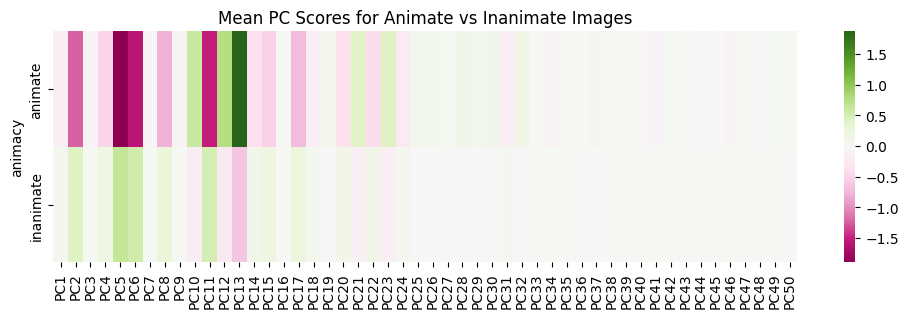

In [ ]:
plt.figure(figsize=(12, 3))
sns.heatmap(animacy_means, cmap='PiYG')
plt.title("Mean PC Scores for Animate vs Inanimate Images")
plt.show()

#***Supervised Task***

---

Can a classifier determine whether the subject was looking at a face based solely on the brain activity?

In [ ]:
#Create X and y labels
X = df[[f"PC{i}" for i in range (1,51)]].values
y = df['category'].values

#Remove scrambledpix because not real category for analysis
mask = y != 'scrambledpix'
X = X[mask]
y = y[mask]

print(f"Post scrambledpix datashape: {X.shape}")
print(f"Categories: {np.unique(y)}")

Post scrambledpix datashape: (756, 50)
Categories: ['bottle' 'cat' 'chair' 'face' 'house' 'scissors' 'shoe']


In [ ]:
#Filter for face vs. not face images
y_face = (y == 'face').astype(int)
print(f'Face trials (y=1): {y_face.sum()}')
print(f'Non-face trials (y=0): {(y_face==0).sum()}')

Face trials (y=1): 108
Non-face trials (y=0): 648


In [ ]:
#Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y_face, test_size=0.2, random_state=42, stratify=y_face)

#Regression
model = LogisticRegression(max_iter=2000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

#Test accuracy + cross validation
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy}")

cross_val = cross_val_score(model, X, y_face, cv=5)
print(f"Cross-validation scores: {cross_val}")

Accuracy: 0.9868421052631579
Cross-validation scores: [0.98684211 0.95364238 0.81456954 0.90066225 0.8807947 ]


In [ ]:
#Sanity check
print("Total samples:", len(y))
print("Face count:", sum(y=='face'))
print("Binary positives:", y_face.sum())

Total samples: 756
Face count: 108
Binary positives: 108


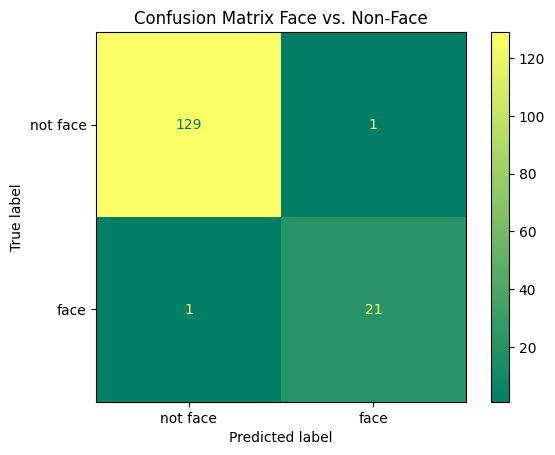

In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels = ['not face', 'face'])
disp.plot(cmap = "summer")
plt.title("Confusion Matrix Face vs. Non-Face")
plt.show()

In [ ]:
#K-NEAREST NEIGHBORS
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

Best k: 1


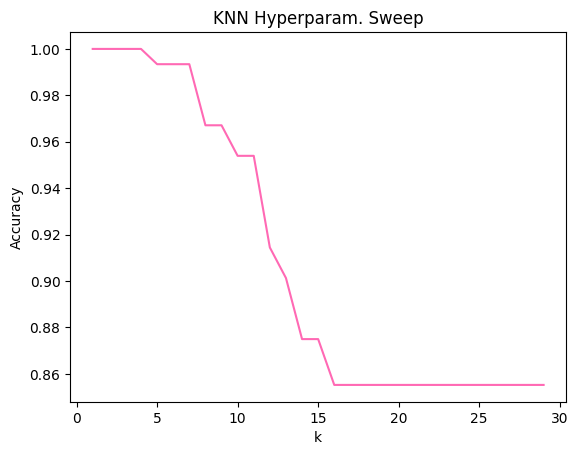

In [ ]:
#Pick k
k_values = range(1, 30)
scores = []
for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)
    scores.append(model.score(X_test, y_test))

best_k = list(k_values)[np.argmax(scores)]
print(f"Best k: {best_k}")

# Sweep
plt.plot(list(k_values), scores, color = 'hotpink')
plt.xlabel("k")
plt.ylabel("Accuracy")
plt.title("KNN Hyperparam. Sweep")
plt.show()


In [ ]:
#KNN vs. Logistic Regression

cv = StratifiedKFold(n_splits = 5, shuffle = True, random_state = 42)

linear_scores = cross_val_score(LogisticRegression(max_iter = 2000), X, y_face, cv = cv, scoring = 'accuracy')
KNN_scores = cross_val_score(KNeighborsClassifier(n_neighbors = 5), X_scaled, y_face, cv = cv, scoring = 'accuracy')

print(f"Logistic Regression: {linear_scores.mean():.3f}")
print(f"KNN (k=5): {KNN_scores.mean():.3f}")

Logistic Regression: 0.991
KNN (k=5): 0.983


#***Unsupervised Task***
---
 How do images sit in the brain's representational space?

In [ ]:
#Setup PCA
pca = PCA(n_components = 2)
X_pca = pca.fit_transform(X)

pca.explained_variance_ratio_

array([0.37907103, 0.13632541])

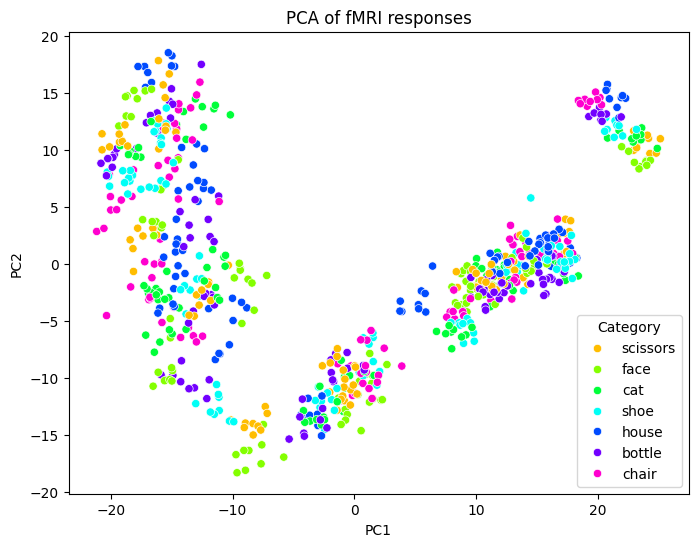

In [ ]:
#Plot PCA
plt.figure(figsize = (8,6))
sns.scatterplot(x = X_pca[:,0], y = X_pca[:,1], hue = y, palette = 'hsv')
plt.title("PCA of fMRI responses")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend(title = "Category")
plt.show()

In [ ]:
#t-SNE
tsne = TSNE(n_components = 2, random_state = 42, max_iter = 1000)
X_tsne = tsne.fit_transform(X)

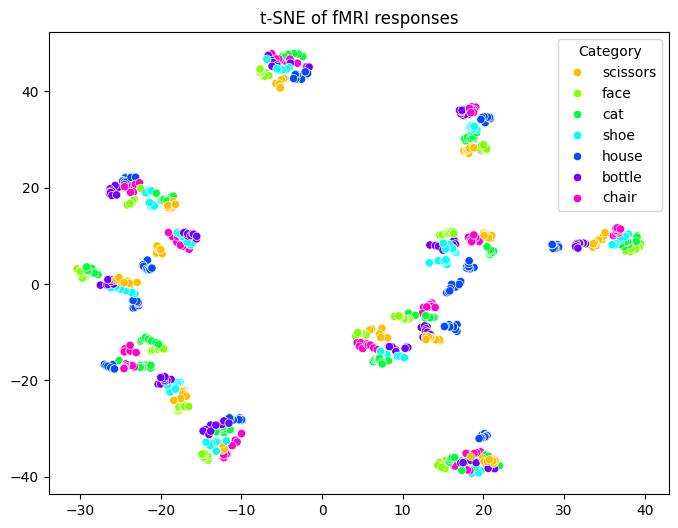

In [ ]:
#Plot t-SNE
plt.figure(figsize = (8,6))
sns.scatterplot(x = X_tsne[:,0], y = X_tsne[:,1], hue = y, palette = 'hsv')
plt.title("t-SNE of fMRI responses")
plt.legend(title = "Category")
plt.show()

Text(0, 0.5, 't-SNE 2')

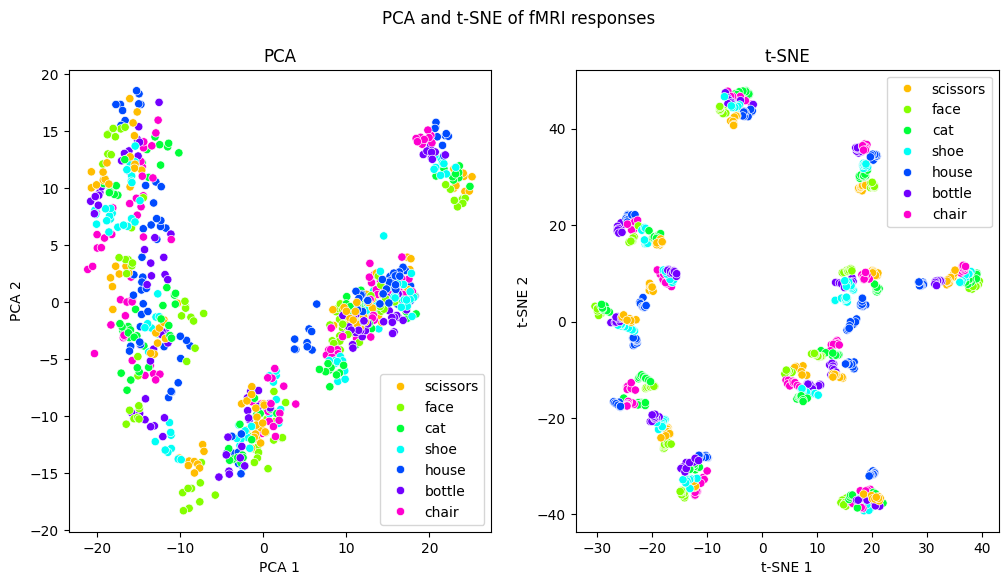

In [ ]:
#Comparison
fig, axes = plt.subplots(1, 2, figsize = (12,6))
fig.suptitle("PCA and t-SNE of fMRI responses")
#PCA
sns.scatterplot(x = X_pca[:,0], y = X_pca[:,1], hue = y, palette = 'hsv', ax = axes[0])
axes[0].set_title("PCA")
axes[0].set_xlabel("PCA 1")
axes[0].set_ylabel("PCA 2")
#t-SNE
sns.scatterplot(x=X_tsne[:, 0], y=X_tsne[:, 1], hue=y, palette='hsv', ax=axes[1])
axes[1].set_title("t-SNE", fontsize=12)
axes[1].set_xlabel("t-SNE 1")
axes[1].set_ylabel("t-SNE 2")